# import

In [42]:
import os
import gzip
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# configs

In [43]:
DATA_ROOT = "./data/Town04_Rep0_Town04_Scenario4_102_route0_11_08_03_33_41"

# check measurement

In [44]:
def get_gz_json(file_path):
    with gzip.open(file_path, "rt", encoding="utf-8") as f:
        data = json.load(f)
    return data


m_path = os.path.join(DATA_ROOT, "measurements/0000.json.gz")
data = get_gz_json(m_path)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['pos_global', 'theta', 'speed', 'target_speed', 'speed_limit', 'target_point', 'target_point_next', 'command', 'next_command', 'aim_wp', 'route', 'route_original', 'changed_route', 'speed_reduced_by_obj_type', 'speed_reduced_by_obj_id', 'speed_reduced_by_obj_distance', 'steer', 'throttle', 'brake', 'control_brake', 'junction', 'vehicle_hazard', 'vehicle_affecting_id', 'light_hazard', 'walker_hazard', 'walker_affecting_id', 'stop_sign_hazard', 'stop_sign_close', 'walker_close', 'walker_close_id', 'angle', 'augmentation_translation', 'augmentation_rotation', 'ego_matrix'])


In [45]:
m_df = pd.DataFrame([data])
m_df.head()

,pos_global,theta,speed,target_speed,speed_limit,target_point,target_point_next,command,next_command,aim_wp,...,walker_hazard,walker_affecting_id,stop_sign_hazard,stop_sign_close,walker_close,walker_close_id,angle,augmentation_translation,augmentation_rotation,ego_matrix
0,"[210.31028747558594, -135.08680725097656]",-2.190257,0.234644,1.428359,13.888889,"[26.932974209958672, 8.900428674038592]","[41.99795014311358, 6.522442694547377]",4,4,"[10.259591268383854, 1.1818218665540612]",...,False,None,True,True,False,None,0.073012,-0.72961,3.438891,"[[-0.5805959701538086, 0.8141918182373047, -2...."


In [46]:
measurement_dir = Path(DATA_ROOT + "/measurements")

rows = []

for file in sorted(measurement_dir.glob("*.json.gz")):
    with gzip.open(file, "rt", encoding="utf-8") as f:
        data = json.load(f)

    data["frame"] = file.stem   # frame id 추가
    rows.append(data)

df = pd.DataFrame(rows)

print(df.head())
print(df.columns)

                                  pos_global     theta     speed  \
0  [210.31028747558594, -135.08680725097656] -2.190257  0.234644   
1  [210.31028747558594, -135.08673095703125] -2.190257  0.091376   
2   [210.3102264404297, -135.08670043945312] -2.190255  0.025350   
3   [210.20651245117188, -135.2887725830078] -2.168172  1.476998   
4  [209.95135498046875, -135.77871704101562] -2.129486  2.936521   

   target_speed  speed_limit                             target_point  \
0      1.428359    13.888889  [26.932974209958672, 8.900428674038592]   
1      1.035210    13.888889   [26.933036327867924, 8.90047296999147]   
2      0.969985    13.888889  [26.933038470566913, 8.900501854688553]   
3      2.338735    13.888889   [26.89759909322755, 8.275689090702318]   
4      3.666817    13.888889   [26.64684126101748, 7.185867772201446]   

                        target_point_next  command  next_command  \
0  [41.99795014311358, 6.522442694547377]        4             4   
1  [41.998012261

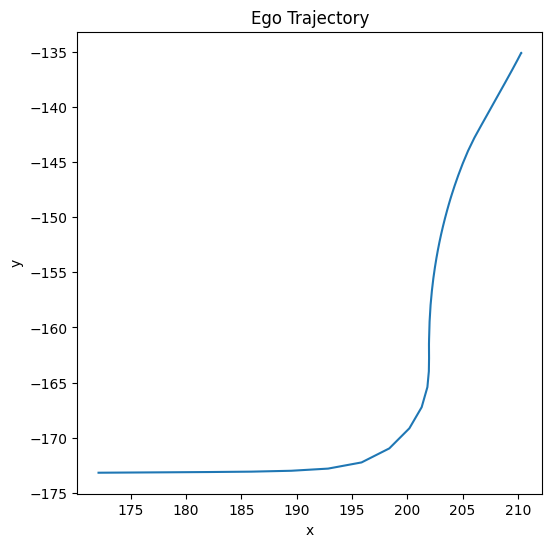

In [47]:
xs = df["pos_global"].apply(lambda x: x[0])
ys = df["pos_global"].apply(lambda x: x[1])

plt.figure(figsize=(6, 6))
plt.plot(xs, ys)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ego Trajectory")
plt.show()

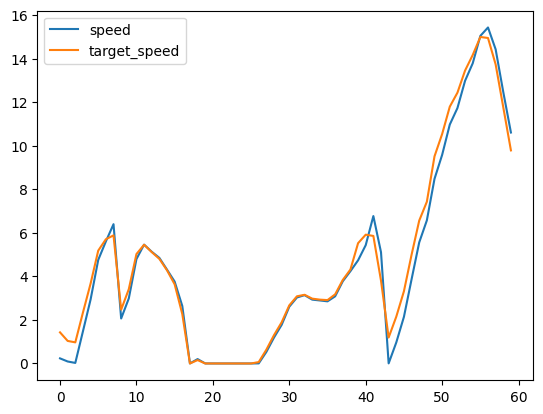

In [48]:
plt.plot(df["speed"], label="speed")
plt.plot(df["target_speed"], label="target_speed")
plt.legend()

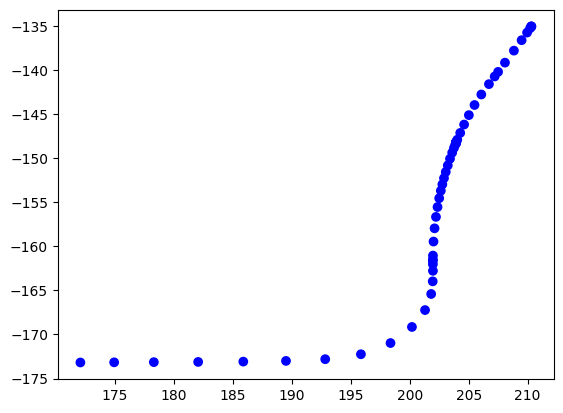

In [49]:
colors = df["vehicle_hazard"].map({True:"red", False:"blue"})

plt.scatter(xs, ys, c=colors)

# BEV Semantics

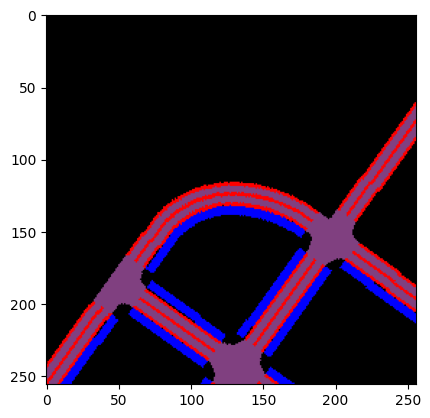

In [50]:
from PIL import Image

def visualize_semantic_mask(mask, color_map=None):
    """
    mask: (H, W) uint8/int array
    returns: RGB image (H, W, 3)
    """

    if color_map is None:
        color_map = {
            0: (0, 0, 0),         # black
            1: (128, 64, 128),   # road
            2: (0, 0, 255),      # vehicle
            3: (255, 0, 0),      # pedestrian
            4: (0, 255, 0),      # vegetation
            5: (255, 255, 0),    # lane
        }

    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        rgb[mask == class_id] = color

    return rgb

test_img_path = os.path.join(DATA_ROOT, 'bev_semantics', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
plt.imshow(rgb)

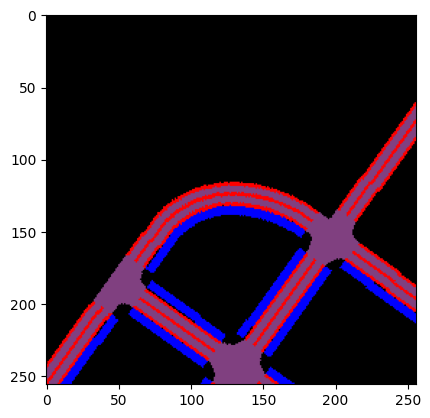

In [51]:
test_img_path = os.path.join(DATA_ROOT, 'bev_semantics_augmented', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
plt.imshow(rgb)

# lidar

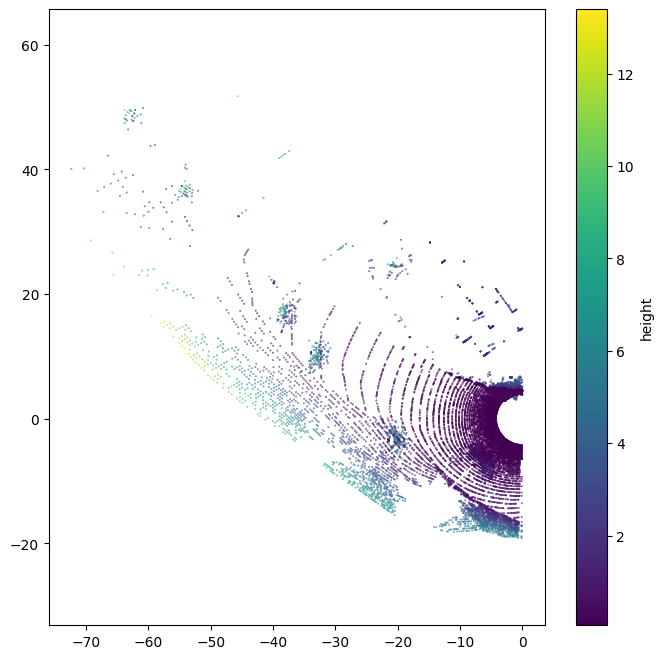

In [52]:
import laspy

test_lidar_path = os.path.join(DATA_ROOT, "lidar", "0000.laz")
las = laspy.read(test_lidar_path)

x = las.x
y = las.y
z = las.z

plt.figure(figsize=(8,8))
plt.scatter(x, y, s=0.1, c=z)
plt.axis("equal")
plt.colorbar(label="height")
plt.show()

In [53]:
import open3d as o3d
import numpy as np

points = np.vstack([x, y, z]).T

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

o3d.visualization.draw_geometries([pcd])

# box, RGB, depth, Semantic

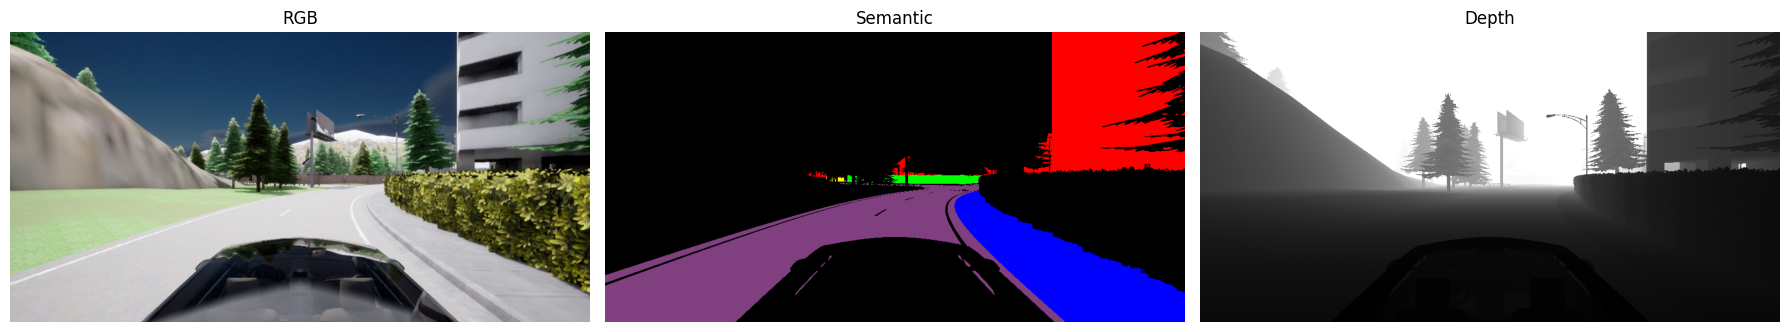

In [54]:
def visualize_sample(index):
    """
    Visualize RGB / Semantic / Depth together
    """

    idx = f"{index:04d}"

    rgb_path = os.path.join(DATA_ROOT, "rgb", idx+".jpg")
    semantic_path = os.path.join(DATA_ROOT, "semantics", idx+".png")
    depth_path = os.path.join(DATA_ROOT, "depth", idx+".png")

    # RGB
    rgb = np.array(Image.open(rgb_path))

    # Semantic
    semantic_mask = np.array(Image.open(semantic_path))
    semantic_rgb = visualize_semantic_mask(semantic_mask)

    # Depth
    depth_vis = Image.open(depth_path)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    axes[1].imshow(semantic_rgb)
    axes[1].set_title("Semantic")
    axes[1].axis("off")

    axes[2].imshow(depth_vis, cmap="gray")
    axes[2].set_title("Depth")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_sample(0)

In [55]:
boxes = get_gz_json(os.path.join(DATA_ROOT, "boxes", "0000.json.gz"))
rgb_path = os.path.join(DATA_ROOT, "rgb", "0000.jpg")

# records/results json

In [56]:
records = get_gz_json(os.path.join(DATA_ROOT, "records.json.gz"))
results = get_gz_json(os.path.join(DATA_ROOT, "results.json.gz"))

print(records)
print(results)

{'meta_data': {'index': 'Town04_Scenario4_102_route0_11_08_03_33_41', 'town': 'Carla/Maps/Town04'}, 'states': [], 'lights': [], 'route': [], 'ego_actions': [], 'adv_actions': []}
{'timestamp': 'Town04_Scenario4_102_route0_11_08_03_33_41', 'index': 0, 'route_id': 'RouteScenario_102_rep0', 'status': 'Completed', 'num_infractions': 1, 'infractions': {'collisions_layout': [], 'collisions_pedestrian': [], 'collisions_vehicle': [], 'red_light': [], 'stop_infraction': [], 'outside_route_lanes': [], 'min_speed_infractions': ["Average speed is 75.61% of the surrounding traffic's one"], 'yield_emergency_vehicle_infractions': [], 'scenario_timeouts': [], 'route_dev': [], 'vehicle_blocked': [], 'route_timeout': []}, 'scores': {'score_route': 100, 'score_penalty': 0.92683, 'score_composed': 92.683}, 'meta': {'route_length': 75.956, 'duration_game': 14.85, 'duration_system': 65.097}}
